In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!pip install spacy pandas
!python -m spacy download sl_core_news_lg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.0/232.0 MB 6.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('sl_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
"""Utilities to compute named-entity counts per document in Google Colab."""
from __future__ import annotations

import ast
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional

import pandas as pd
import spacy

LABEL_NORMALIZATION = {
    "PERSON": "PERSON",
    "PER": "PERSON",
    "LOC": "LOC",
    "GPE": "GPE",
    "ORG": "ORG",
    "MISC": "MISC",
}


@dataclass
class NerConfig:
    input_csv: Path
    output_csv: Path
    text_column: str = "content"
    id_column: Optional[str] = None
    date_column: str = "date"
    ref_column: Optional[str] = "ref"
    spacy_model: str = "sl_core_news_lg"


def extract_site(ref_value: str) -> str:
    """Return the first `site` value from the ref column, if available."""
    if not ref_value or pd.isna(ref_value):
        return ""
    if isinstance(ref_value, list):
        items = ref_value
    else:
        try:
            parsed = ast.literal_eval(str(ref_value))
        except (ValueError, SyntaxError):
            return ""
        items = parsed if isinstance(parsed, list) else [parsed]
    for item in items:
        if isinstance(item, dict) and item.get("site"):
            return str(item["site"]).strip()
    return ""


def resolve_id_column(df: pd.DataFrame, id_column: Optional[str]) -> str:
    if id_column and id_column in df.columns:
        return id_column
    return df.columns[0]


def load_spacy_model(model_name: str) -> spacy.language.Language:
    try:
        return spacy.load(model_name)
    except OSError as exc:  # pragma: no cover - dependency guard
        raise RuntimeError(
            f"Unable to load spaCy model '{model_name}'. "
            "Run `python -m spacy download en_core_web_sm` in Colab first."
        ) from exc


def generate_entity_counts(df: pd.DataFrame, config: NerConfig) -> pd.DataFrame:
    nlp = load_spacy_model(config.spacy_model)
    id_column = resolve_id_column(df, config.id_column)

    records: List[dict] = []

    for _, row in df.iterrows():
        text = str(row.get(config.text_column, "")).strip()
        if not text:
            continue

        doc = nlp(text)
        ref_value = row.get(config.ref_column, "") if config.ref_column else ""
        doc_id = str(row.get(id_column, "")).strip()
        doc_date = str(row.get(config.date_column, "")).strip()

        counts: Counter = Counter()
        canonical: dict[tuple[str, str], str] = {}
        for ent in doc.ents:
            normalized_label = LABEL_NORMALIZATION.get(ent.label_)
            if not normalized_label:
                continue
            entity_text = ent.text.strip()
            if not entity_text:
                continue
            norm_key = (normalized_label, entity_text.lower())
            counts[norm_key] += 1
            canonical.setdefault(norm_key, entity_text)

        for (label, norm), freq in counts.items():
            records.append(
                {
                    "document_id": int(doc_id)+1,
                    "entity_type": label,
                    "entity": canonical[(label, norm)],
                    "frequency": freq,
                    "date": doc_date,
                }
            )

    columns = ["document_id", "entity_type", "entity", "frequency", "date"]
    return pd.DataFrame(records, columns=columns)


def run_pipeline(config: NerConfig) -> pd.DataFrame:
    df = pd.read_csv(config.input_csv)
    result = generate_entity_counts(df, config)
    result.to_csv(config.output_csv, index=False)
    return result





In [ ]:
import pandas as pd
df = pd.read_csv('/content/gdrive/MyDrive/slovene_data_2025/slovenian_dataset.csv')
df.head()

,Unnamed: 0.2,article_id,title,subtitle,slug,date,tags,content,Unnamed: 0.1,Unnamed: 0
0,0,613261,Življenje brez mobilnega signala in interneta,V Sloveniji en odstotek gospodinjstev ni pokri...,"""Ko grem delat v gozd ali ko grem od doma, tel...",10-04-2022,internet; brez signala; mobilni telefon,"Med hribi, ki ločijo Tolmin od Bohinja, na 744...",NaN,NaN
1,1,614984,"SAB z geslom ""Naredimo, kar je treba"" poudarja...",Stranka več pozornosti namenja upokojencem,Stranka Alenke Bratušek (SAB) se kot del koali...,22-03-2022,Stranka Alenke Bratušek; SAB; volilni program;...,Prioritete stranke bodo po besedah predsednice...,NaN,NaN
2,2,615225,NSi v središče postavlja razvoj okolja za mlad...,"V stranki si prizadevajo, da bi bili tudi po v...",Nova Slovenija (NSi) se na volitve odpravlja z...,25-03-2022,NSi; program; volitve,"V stranki Novi Sloveniji (NSi) napovedujejo, d...",NaN,NaN
3,3,615316,Mit ali resnica? 6 trditev o kolagenu!,"Kolagen, prehransko dopolnilo, ki je preplavi...",,20-06-2022,kolagen; canabia kolagen; kolagen v prahu,"Kolagen je beljakovina, ki je odgovorna za zdr...",NaN,NaN
4,4,615562,"Olimpija zanesljivo do 17. naslova, Triglavu l...",Triglav v 20. minuti z igralcem več dosegel ča...,Hokejisti SŽ-ja Olimpije so novi državni prvak...,5-04-2022,hokej; državno prvenstvo; finale; SŽ Olimpija;...,Zmaji so zadnjič dvignili pokal državnih prvak...,NaN,NaN


RangeIndex(start=0, stop=9869, step=1)

In [ ]:

from pathlib import Path
ENG_PATH = "/content/gdrive/MyDrive/RUWA_new.csv"
SLO_PATH = "/content/gdrive/MyDrive/slovene_data_2025/slovenian_dataset.csv"
OUTPUT_PATH = "/content/gdrive/MyDrive/slovene_data_2025/slovene_entity_counts.csv"


SLOVENE_CONFIG = NerConfig(
    input_csv=SLO_PATH,
    output_csv=OUTPUT_PATH,
    text_column="content",
    id_column="order",
    date_column="date",
    ref_column=None,
)

entity_counts = run_pipeline(SLOVENE_CONFIG)


In [ ]:
from pathlib import Path
ENG_PATH = "/content/gdrive/MyDrive/RUWA_new.csv"
SLO_PATH = "/content/gdrive/MyDrive/slo_data/pandas_df.pkl"
OUTPUT_PATH = "/content/gdrive/MyDrive/english_data/eng_entity_counts.csv"
cfg = NerConfig(
    input_csv=Path(ENG_PATH),
    output_csv=Path(OUTPUT_PATH),
)
entity_counts = run_pipeline(cfg)
entity_counts

,document_id,entity_type,entity,frequency,date,site
0,1,GPE,Ukraine,7,02/28/2022,bbc.com
1,1,ORG,FebruarySharecloseShare,1,02/28/2022,bbc.com
2,1,ORG,TopicsRussia-Ukraine warImage,1,02/28/2022,bbc.com
3,1,PERSON,Getty ImagesImage,2,02/28/2022,bbc.com
4,1,GPE,Chuhuiv,2,02/28/2022,bbc.com
...,...,...,...,...,...,...
326547,264,ORG,TASS,1,09/29/2022,tass.com
326548,264,ORG,LPR,1,09/29/2022,tass.com
326549,264,LOC,the Kherson Region,1,09/29/2022,tass.com
326550,264,LOC,the Zaporozhye Region,1,09/29/2022,tass.com


In [ ]:
"""Colab utilities for time-series analysis of NER entity counts."""
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Optional, Sequence

import matplotlib.pyplot as plt
import pandas as pd


@dataclass
class TimeSeriesConfig:
    input_csv: Path
    date_column: str = "date"
    entity_type_column: str = "entity_type"
    entity_column: str = "entity"
    frequency_column: str = "frequency"
    rolling_window: Optional[int] = None
    include_entity_types: Optional[Sequence[str]] = None
    include_entities: Optional[Sequence[str]] = None
    case_insensitive_entities: bool = True
    column_filters: Dict[str, Sequence[str]] = field(default_factory=dict)
    case_insensitive_columns: Optional[Sequence[str]] = None
    group_columns: Optional[Sequence[str]] = None
    top_n: Optional[int] = None




def apply_filters(df: pd.DataFrame, config: TimeSeriesConfig) -> pd.DataFrame:
    filtered = df

    insensitive_columns = {col.lower() for col in (config.case_insensitive_columns or [])}

    if config.column_filters:
        for column, values in config.column_filters.items():
            if column not in filtered.columns:
                raise ValueError(
                    f"Missing column '{column}' required for filtering in {config.input_csv}"
                )
            allowed = [value for value in values if value is not None]
            if not allowed:
                continue
            if column.lower() in insensitive_columns:
                allowed_lower = {str(value).lower() for value in allowed}
                mask = filtered[column].astype(str).str.lower().isin(allowed_lower)
            else:
                mask = filtered[column].isin(allowed)
            filtered = filtered[mask]

    if config.include_entity_types:
        valid_types = {value.strip() for value in config.include_entity_types if value is not None}
        if valid_types:
            if config.entity_type_column not in filtered.columns:
                raise ValueError(
                    f"Missing entity type column '{config.entity_type_column}' in {config.input_csv}"
                )
            filtered = filtered[filtered[config.entity_type_column].isin(valid_types)]

    if config.include_entities:
        if config.entity_column not in filtered.columns:
            raise ValueError(
                f"Missing entity column '{config.entity_column}' in {config.input_csv}"
            )
        entities = [str(v) for v in config.include_entities if v is not None]
        if entities:
            series = filtered[config.entity_column].astype(str)
            if config.case_insensitive_entities or config.entity_column.lower() in insensitive_columns:
                target = {v.lower() for v in entities}
                mask = series.str.lower().isin(target)
            else:
                mask = series.isin(entities)
            filtered = filtered[mask]

    return filtered


def load_entity_counts(config: TimeSeriesConfig) -> pd.DataFrame:
    df = pd.read_csv(config.input_csv)
    if config.date_column not in df.columns:
        raise ValueError(f"Missing date column '{config.date_column}' in {config.input_csv}")
    df[config.date_column] = pd.to_datetime(df[config.date_column], errors="coerce")
    df = df.dropna(subset=[config.date_column])
    return apply_filters(df, config)


def aggregate_timeseries(df: pd.DataFrame, config: TimeSeriesConfig) -> pd.DataFrame:
    if config.group_columns:
        group_cols = [col for col in config.group_columns if col]
    else:
        has_entity_filter = any(value is not None for value in (config.include_entities or []))
        group_cols = [config.entity_column] if has_entity_filter else [config.entity_type_column]

    group_cols = list(dict.fromkeys(group_cols))  # preserve order, remove duplicates
    if not group_cols:
        raise ValueError("At least one grouping column must be specified")

    missing = [col for col in group_cols if col not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns {missing} required for grouping in {config.input_csv}"
        )

    working_df = df.copy()
    if len(group_cols) == 1:
        pivot_column = group_cols[0]
    else:
        pivot_column = "__series_label"
        working_df[pivot_column] = (
            working_df[group_cols]
            .astype(str)
            .agg(" | ".join, axis=1)
        )

    grouped = (
        working_df.groupby(
            [pivot_column, pd.Grouper(key=config.date_column, freq="D")]
        )[config.frequency_column]
        .sum()
        .reset_index()
    )

    pivot = grouped.pivot(
        index=config.date_column,
        columns=pivot_column,
        values=config.frequency_column,
    )

    pivot = pivot.sort_index().fillna(0)

    if config.top_n and config.top_n > 0 and pivot.shape[1] > 0:
        totals = pivot.sum(axis=0).sort_values(ascending=False)
        keep_columns = totals.head(config.top_n).index
        pivot = pivot.loc[:, keep_columns]

    if config.rolling_window:
        pivot = pivot.rolling(window=config.rolling_window, min_periods=1).mean()

    pivot.index.name = "date"
    pivot.columns.name = (
        " / ".join(group_cols) if len(group_cols) > 1 else group_cols[0]
    )
    return pivot


def plot_timeseries(data: pd.DataFrame, figsize=(12, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    for column in data.columns:
        ax.plot(data.index, data[column], label=column)
    series_label = data.columns.name or "Series"
    legend_title = series_label.replace('_', ' ').title()
    ax.set_xlabel("Date")
    ax.set_ylabel("Entity count")
    ax.set_title(f"{legend_title} frequency over time")
    ax.legend(title=legend_title)
    fig.autofmt_xdate()
    return fig, ax


def run_timeseries_pipeline(config: TimeSeriesConfig, output_csv: Optional[Path] = None):
    df = load_entity_counts(config)
    timeseries = aggregate_timeseries(df, config)
    if output_csv:
        timeseries.to_csv(output_csv)
    return timeseries


In [ ]:
"""Colab utilities for time-series analysis of NER entity counts."""
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Optional, Sequence

import matplotlib.pyplot as plt
import pandas as pd
import re


@dataclass
class TimeSeriesConfig:
    input_csv: Path
    date_column: str = "date"
    entity_type_column: str = "entity_type"
    entity_column: str = "entity"
    frequency_column: str = "frequency"
    rolling_window: Optional[int] = None
    include_entity_types: Optional[Sequence[str]] = None
    include_entities: Optional[Sequence[str]] = None
    case_insensitive_entities: bool = True
    column_filters: Dict[str, Sequence[str]] = field(default_factory=dict)
    case_insensitive_columns: Optional[Sequence[str]] = None
    group_columns: Optional[Sequence[str]] = None
    top_n: Optional[int] = None
    merge_entity_subsets: bool = False




def _tokenize_entity(value: str) -> tuple[str, ...]:
    if not value:
        return tuple()
    return tuple(re.findall(r"\w+", value.lower()))


def _build_canonical_map(values: Sequence[str]) -> dict[str, str]:
    """Return mapping from normalized value to canonical value using token subset rule."""
    canonical_map: dict[str, str] = {}
    canonical_tokens: list[tuple[str, set[str]]] = []

    unique_values = []
    seen = set()
    for raw in values:
        candidate = str(raw).strip()
        if not candidate:
            continue
        norm = candidate.lower()
        if norm in seen:
            continue
        seen.add(norm)
        unique_values.append(candidate)

    for value in sorted(unique_values, key=len, reverse=True):
        norm = value.lower()
        tokens = set(_tokenize_entity(value))
        matched = None
        for canon_norm, canon_tokens in canonical_tokens:
            if tokens and tokens.issubset(canon_tokens):
                matched = canon_norm
                break
        if matched is None:
            canonical_tokens.append((norm, tokens))
            canonical_map[norm] = value
        else:
            canonical_map[norm] = canonical_map[matched]
    return canonical_map



def merge_subset_entities(
    df: pd.DataFrame,
    entity_type_column: str,
    entity_column: str,
    frequency_column: str,
) -> tuple[pd.DataFrame, dict[str, set[str]]]:
    """Merge rows where an entity text is a subset of another entity's tokens."""
    if df.empty:
        return df, {}

    if frequency_column not in df.columns:
        raise ValueError(f"Missing frequency column '{frequency_column}' in input data")

    working = df.copy()

    unique = (
        working[[entity_type_column, entity_column]]
        .dropna()
        .drop_duplicates()
    )

    mapping: dict[tuple[str, str], str] = {}
    lookup: dict[str, set[str]] = {}

    for entity_type, group in unique.groupby(entity_type_column):
        values = [str(value).strip() for value in group[entity_column] if str(value).strip()]
        if not values:
            continue
        canonical_map = _build_canonical_map(values)
        for value in values:
            norm = value.lower()
            canonical = canonical_map.get(norm, value)
            key = (str(entity_type), norm)
            mapping[key] = canonical
            lookup.setdefault(norm, set()).add(canonical)

    if not mapping:
        return df, lookup

    entity_values = working[entity_column].astype(str)
    entity_types = working[entity_type_column].astype(str)
    canonical_entities: list[str] = []
    for etype, value in zip(entity_types, entity_values):
        norm = value.lower()
        canonical = mapping.get((etype, norm))
        canonical_entities.append(canonical if canonical else value)

    working[entity_column] = canonical_entities
    working[frequency_column] = pd.to_numeric(working[frequency_column], errors="coerce").fillna(0)

    group_cols = [col for col in working.columns if col != frequency_column]
    merged = (
        working.groupby(group_cols, dropna=False)[frequency_column]
        .sum()
        .reset_index()
    )

    for canonical in merged[entity_column].dropna().unique():
        lookup.setdefault(canonical.lower(), set()).add(canonical)

    return merged, lookup




def apply_filters(
    df: pd.DataFrame, config: TimeSeriesConfig, canonical_lookup: Optional[dict[str, set[str]]] = None
) -> pd.DataFrame:
    filtered = df

    insensitive_columns = {col.lower() for col in (config.case_insensitive_columns or [])}

    if config.column_filters:
        for column, values in config.column_filters.items():
            if column not in filtered.columns:
                raise ValueError(
                    f"Missing column '{column}' required for filtering in {config.input_csv}"
                )
            allowed = [value for value in values if value is not None]
            if not allowed:
                continue
            if column.lower() in insensitive_columns:
                allowed_lower = {str(value).lower() for value in allowed}
                mask = filtered[column].astype(str).str.lower().isin(allowed_lower)
            else:
                mask = filtered[column].isin(allowed)
            filtered = filtered[mask]

    if config.include_entity_types:
        valid_types = {value.strip() for value in config.include_entity_types if value is not None}
        if valid_types:
            if config.entity_type_column not in filtered.columns:
                raise ValueError(
                    f"Missing entity type column '{config.entity_type_column}' in {config.input_csv}"
                )
            filtered = filtered[filtered[config.entity_type_column].isin(valid_types)]

    if config.include_entities:
        if config.entity_column not in filtered.columns:
            raise ValueError(
                f"Missing entity column '{config.entity_column}' in {config.input_csv}"
            )
        entities = [str(v) for v in config.include_entities if v is not None]
        if entities:
            if canonical_lookup:
                expanded: set[str] = set()
                for value in entities:
                    value_norm = value.lower()
                    matches = canonical_lookup.get(value_norm)
                    if matches:
                        expanded.update(matches)
                    else:
                        expanded.add(value)
                entities = list(expanded)
            series = filtered[config.entity_column].astype(str)
            if config.case_insensitive_entities or config.entity_column.lower() in insensitive_columns:
                target = {v.lower() for v in entities}
                mask = series.str.lower().isin(target)
            else:
                mask = series.isin(entities)
            filtered = filtered[mask]

    return filtered


def load_entity_counts(config: TimeSeriesConfig) -> pd.DataFrame:
    df = pd.read_csv(config.input_csv)
    if config.date_column not in df.columns:
        raise ValueError(f"Missing date column '{config.date_column}' in {config.input_csv}")
    df[config.date_column] = pd.to_datetime(df[config.date_column], errors="coerce")
    df = df.dropna(subset=[config.date_column])

    canonical_lookup: Optional[dict[str, set[str]]] = None
    if config.merge_entity_subsets:
        df, canonical_lookup = merge_subset_entities(
            df,
            entity_type_column=config.entity_type_column,
            entity_column=config.entity_column,
            frequency_column=config.frequency_column,
        )

    return apply_filters(df, config, canonical_lookup)


def aggregate_timeseries(df: pd.DataFrame, config: TimeSeriesConfig) -> pd.DataFrame:
    if config.group_columns:
        group_cols = [col for col in config.group_columns if col]
    else:
        has_entity_filter = any(value is not None for value in (config.include_entities or []))
        group_cols = [config.entity_column] if has_entity_filter else [config.entity_type_column]

    group_cols = list(dict.fromkeys(group_cols))  # preserve order, remove duplicates
    if not group_cols:
        raise ValueError("At least one grouping column must be specified")

    missing = [col for col in group_cols if col not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns {missing} required for grouping in {config.input_csv}"
        )

    working_df = df.copy()
    if len(group_cols) == 1:
        pivot_column = group_cols[0]
    else:
        pivot_column = "__series_label"
        working_df[pivot_column] = (
            working_df[group_cols]
            .astype(str)
            .agg(" | ".join, axis=1)
        )

    grouped = (
        working_df.groupby(
            [pivot_column, pd.Grouper(key=config.date_column, freq="D")]
        )[config.frequency_column]
        .sum()
        .reset_index()
    )

    pivot = grouped.pivot(
        index=config.date_column,
        columns=pivot_column,
        values=config.frequency_column,
    )

    pivot = pivot.sort_index().fillna(0)

    if config.top_n and config.top_n > 0 and pivot.shape[1] > 0:
        totals = pivot.sum(axis=0).sort_values(ascending=False)
        keep_columns = totals.head(config.top_n).index
        pivot = pivot.loc[:, keep_columns]

    if config.rolling_window:
        pivot = pivot.rolling(window=config.rolling_window, min_periods=1).mean()

    pivot.index.name = "date"
    pivot.columns.name = (
        " / ".join(group_cols) if len(group_cols) > 1 else group_cols[0]
    )
    return pivot


def plot_timeseries(data: pd.DataFrame, figsize=(12, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    for column in data.columns:
        ax.plot(data.index, data[column], label=column)
    series_label = data.columns.name or "Series"
    legend_title = series_label.replace('_', ' ').title()
    ax.set_xlabel("Date")
    ax.set_ylabel("Entity count")
    ax.set_title(f"{legend_title} frequency over time")
    ax.legend(title=legend_title)
    fig.autofmt_xdate()
    return fig, ax


def run_timeseries_pipeline(config: TimeSeriesConfig, output_csv: Optional[Path] = None):
    df = load_entity_counts(config)
    timeseries = aggregate_timeseries(df, config)
    if output_csv:
        timeseries.to_csv(output_csv)
    return timeseries


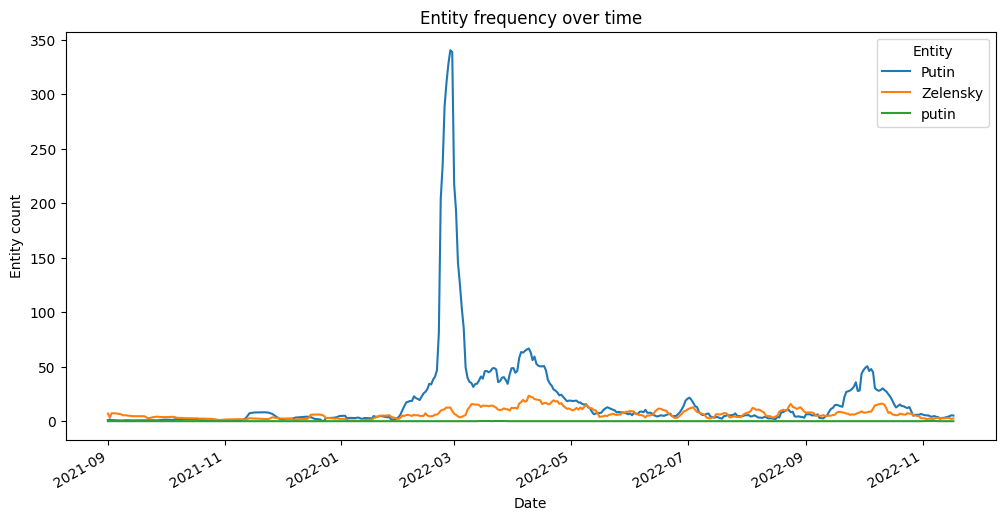

In [ ]:
OUTPUT_PATH = "/content/gdrive/MyDrive/english_data/eng_entity_counts.csv"


config = TimeSeriesConfig(
    input_csv=Path(OUTPUT_PATH),
     group_columns=[ "entity"],
    column_filters={ "entity": ['Putin', "Zelensky"]},
    include_entities=['Putin', "Zelensky"],
    case_insensitive_columns=["entity"],
    top_n=5,
    rolling_window=7,
)

ts_df = run_timeseries_pipeline(config, output_csv=Path("/content/gdrive/MyDrive/english_data/entity_timeseries.csv"))
fig, ax = plot_timeseries(ts_df)
fig.show()